# COMP 352 – Final Project: Footballer Market Evaluation  
**Goal:** Predict a footballer’s **market value next year** using **only historical information** (no future leakage).  

**Authors:** _<YOUR NAMES HERE>_  

**Dataset source:** Kaggle – “player-scores” dataset (players + player_valuations).  
> Add the Kaggle link here: https://www.kaggle.com/datasets/davidcariboo/player-scores  

---

## Table of Contents
1. Environment Setup  
2. Data Importing and Pre-processing  
3. Data Analysis and Visualization  
4. Data Analytics (Modeling)  
5. Summary / Conclusions  


## 1. Environment Setup
This notebook uses common Python data science libraries (pandas, numpy, matplotlib, scikit-learn).

In [19]:

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Modeling
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

# Optional preprocessing (used in pipelines if desired)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
np.set_printoptions(suppress=True)

print("Imports complete.")


Imports complete.


## 2. Data Importing and Pre-processing
We load two datasets:
- `player_valuations.csv`: multiple valuation records per player over time
- `players.csv`: one record per player with demographic and categorical info

We then clean data, engineer historical features, and build a **time-based target**: next year's market value.

In [20]:

# -----------------------------
# 2.1 Load datasets
# -----------------------------
# Option A (recommended): place the Kaggle files under:
#   data/raw/player_valuations.csv
#   data/raw/players.csv
#
# Option B: edit these paths to wherever your CSVs are located.

PATH_PLAYER_VALUATIONS = "data/raw/player_valuations.csv"
PATH_PLAYERS = "data/raw/players.csv"

player_valuations_df = pd.read_csv(PATH_PLAYER_VALUATIONS)
players_df = pd.read_csv(PATH_PLAYERS)

print("player_valuations_df shape:", player_valuations_df.shape)
print("players_df shape:", players_df.shape)

player_valuations_df.head()


player_valuations_df shape: (496606, 5)
players_df shape: (32601, 23)


,player_id,date,market_value_in_eur,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,3057,BE1
1,342216,2001-07-20,100000,1241,SC1
2,3132,2003-12-09,400000,126,TR1
3,6893,2003-12-15,900000,984,GB1
4,10,2004-10-04,7000000,398,IT1


In [21]:

# -----------------------------
# 2.2 Dataset characteristics
# -----------------------------
print("player_valuations_df dtypes:")
display(player_valuations_df.dtypes)

print("\nplayers_df dtypes:")
display(players_df.dtypes)

print("\nMissing values (top 10) - player_valuations_df:")
display(player_valuations_df.isna().sum().sort_values(ascending=False).head(10))

print("\nMissing values (top 10) - players_df:")
display(players_df.isna().sum().sort_values(ascending=False).head(10))


player_valuations_df dtypes:


player_id                               int64
date                                   object
market_value_in_eur                     int64
current_club_id                         int64
player_club_domestic_competition_id    object
dtype: object


players_df dtypes:


player_id                                 int64
first_name                               object
last_name                                object
name                                     object
last_season                               int64
current_club_id                           int64
player_code                              object
country_of_birth                         object
city_of_birth                            object
country_of_citizenship                   object
date_of_birth                            object
sub_position                             object
position                                 object
foot                                     object
height_in_cm                            float64
contract_expiration_date                 object
agent_name                               object
image_url                                object
url                                      object
current_club_domestic_competition_id     object
current_club_name                       


Missing values (top 10) - player_valuations_df:


player_id                              0
date                                   0
market_value_in_eur                    0
current_club_id                        0
player_club_domestic_competition_id    0
dtype: int64


Missing values (top 10) - players_df:


agent_name                     16019
contract_expiration_date       12091
country_of_birth                2799
foot                            2536
city_of_birth                   2455
height_in_cm                    2256
first_name                      2062
highest_market_value_in_eur     1523
market_value_in_eur             1523
country_of_citizenship           383
dtype: int64

### 2.3 Clean and reduce columns (avoid leakage)
We keep only the columns needed for modeling and remove columns that are not useful or could cause leakage (e.g., current market value fields in `players.csv`).

In [37]:

# -----------------------------
# 2.3 Clean player_valuations (pv)
# -----------------------------
pv = player_valuations_df.copy()

# Parse date
pv["date"] = pd.to_datetime(pv["date"], errors="coerce")
pv = pv.dropna(subset=["date"])

# Remove duplicates (same player_id & date)
# pv = pv.drop_duplicates(subset=["player_id", "date"], keep="last")

# Keep essential columns
pv = pv[[
    "player_id",
    "date",
    "market_value_in_eur",
    "current_club_id",
    "player_club_domestic_competition_id"
]].copy()

# Rename for clarity
pv = pv.rename(columns={
    "market_value_in_eur": "market_value_in_eur_valuation",
    "current_club_id": "current_club_id_valuation",
    "player_club_domestic_competition_id": "domestic_competition_id_valuation"
})

print("pv shape:", pv.shape)
pv.head()


pv shape: (496606, 5)


,player_id,date,market_value_in_eur_valuation,current_club_id_valuation,domestic_competition_id_valuation
0,405973,2000-01-20,150000,3057,BE1
1,342216,2001-07-20,100000,1241,SC1
2,3132,2003-12-09,400000,126,TR1
3,6893,2003-12-15,900000,984,GB1
4,10,2004-10-04,7000000,398,IT1


In [38]:

# -----------------------------
# 2.4 Clean players (p)
# -----------------------------
p = players_df.copy()

# Parse birth date
p["date_of_birth"] = pd.to_datetime(p["date_of_birth"], errors="coerce")

# Keep only safe player-level features (no leakage)
keep_player_cols = [
    "player_id",
    "date_of_birth",
    "position",
    "sub_position",
    "foot",
    "height_in_cm"
]
p = p[keep_player_cols].copy()

# Handle missing categoricals
p["position"] = p["position"].fillna("Missing")
p["sub_position"] = p["sub_position"].fillna("Missing")
p["foot"] = p["foot"].fillna("Missing")

# Numeric height + impute
p["height_in_cm"] = pd.to_numeric(p["height_in_cm"], errors="coerce")
p["height_in_cm"] = p["height_in_cm"].fillna(p["height_in_cm"].median())

# Birth date required for age feature
p = p.dropna(subset=["date_of_birth"])

print("p shape:", p.shape)
p.head()


p shape: (32554, 6)


,player_id,date_of_birth,position,sub_position,foot,height_in_cm
0,10,1978-06-09,Attack,Centre-Forward,right,184.0
1,26,1980-08-06,Goalkeeper,Goalkeeper,left,190.0
2,65,1981-01-30,Attack,Centre-Forward,Missing,183.0
3,77,1978-05-08,Defender,Centre-Back,Missing,183.0
4,80,1981-03-18,Goalkeeper,Goalkeeper,right,194.0


### 2.5 Merge datasets
We merge valuation records with player info using `player_id`. Each valuation row becomes a modeling row with player features attached.

In [39]:

# -----------------------------
# 2.5 Merge
# -----------------------------
merged_df = pv.merge(p, on="player_id", how="left")

# Drop valuation rows missing player info (rare)
merged_df = merged_df.dropna(subset=["date_of_birth"])

print("merged_df shape:", merged_df.shape)
merged_df.head()

# -----------------------------
# 2.6 Yearly snapshots (1 row per player per year)
# -----------------------------

# Ensure datetime for valuation date
merged_df["date"] = pd.to_datetime(merged_df["date"], errors="coerce")
merged_df = merged_df.dropna(subset=["date"])

# Create a year column
merged_df["year"] = merged_df["date"].dt.year

# Keep ONLY the last valuation within each year per player
merged_df = (
    merged_df.sort_values(["player_id", "date"])
             .groupby(["player_id", "year"], as_index=False)
             .tail(1)
             .reset_index(drop=True)
)

print("merged_df shape after yearly snapshot:", merged_df.shape)
merged_df[["player_id", "date", "year", "market_value_in_eur_valuation"]].head()


merged_df shape: (496045, 10)
merged_df shape after yearly snapshot: (251792, 11)


,player_id,date,year,market_value_in_eur_valuation
0,10,2004-10-04,2004,7000000
1,10,2005-09-30,2005,15000000
2,10,2006-07-15,2006,30000000
3,10,2007-06-21,2007,23000000
4,10,2008-06-04,2008,20000000


In [40]:
# -----------------------------
# 2.6 Yearly snapshots (1 row per player per year)
# -----------------------------
# The valuation dataset may contain multiple records per player in the same year.
# To truly predict "next year's" market value, we create a yearly snapshot by keeping
# the LAST valuation entry of each year for each player.

merged_df["date"] = pd.to_datetime(merged_df["date"], errors="coerce")
merged_df = merged_df.dropna(subset=["date"])

merged_df["year"] = merged_df["date"].dt.year

# Keep only the last valuation in each (player_id, year)
merged_df = (
    merged_df.sort_values(["player_id", "date"])
             .groupby(["player_id", "year"], as_index=False)
             .tail(1)
             .reset_index(drop=True)
)

print("merged_df shape after yearly snapshot:", merged_df.shape)
merged_df[["player_id", "date", "year", "market_value_in_eur_valuation"]].head()

merged_df shape after yearly snapshot: (251792, 11)


,player_id,date,year,market_value_in_eur_valuation
0,10,2004-10-04,2004,7000000
1,10,2005-09-30,2005,15000000
2,10,2006-07-15,2006,30000000
3,10,2007-06-21,2007,23000000
4,10,2008-06-04,2008,20000000


### 2.6 Feature Engineering
We compute age at valuation date and create historical features (lags, trends, rolling mean). We also build the target: next year's market value.

In [41]:
# -----------------------------
# 2.7 Feature Engineering (time series per player, yearly)
# -----------------------------
# At this point, merged_df has ONE row per player per year (yearly snapshot).
# We now compute age, create a next-year target, and build historical lag features.

merged_df = merged_df.sort_values(["player_id", "year"]).reset_index(drop=True)

# Age at time of valuation
merged_df["age_at_valuation"] = ((merged_df["date"] - merged_df["date_of_birth"]).dt.days / 365.25)

# Target: next year's value (t+1 year)
merged_df["market_value_next_year"] = (
    merged_df.groupby("player_id")["market_value_in_eur_valuation"].shift(-1)
)

# Historical lags (past only)
merged_df["market_value_lag_1"] = (
    merged_df.groupby("player_id")["market_value_in_eur_valuation"].shift(1)
)
merged_df["market_value_lag_2"] = (
    merged_df.groupby("player_id")["market_value_in_eur_valuation"].shift(2)
)

# Dynamics
merged_df["market_value_trend"] = merged_df["market_value_lag_1"] - merged_df["market_value_lag_2"]

# Rolling mean (past only) - use shift(1) then rolling window
merged_df["market_value_mean_3"] = (
    merged_df.groupby("player_id")["market_value_in_eur_valuation"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

# Drop rows without enough history or target
merged_df = merged_df.dropna(subset=[
    "market_value_next_year",
    "market_value_lag_1",
    "market_value_lag_2",
    "market_value_mean_3",
    "age_at_valuation"
])

print("merged_df shape after FE:", merged_df.shape)
merged_df[["player_id","year","market_value_in_eur_valuation","market_value_next_year","market_value_lag_1","market_value_lag_2"]].head(10)

merged_df shape after FE: (138509, 17)


,player_id,year,market_value_in_eur_valuation,market_value_next_year,market_value_lag_1,market_value_lag_2
3,10,2007,23000000,20000000.0,30000000.0,15000000.0
4,10,2008,20000000,12000000.0,23000000.0,30000000.0
5,10,2009,12000000,7500000.0,20000000.0,23000000.0
6,10,2010,7500000,5000000.0,12000000.0,20000000.0
7,10,2011,5000000,6000000.0,7500000.0,12000000.0
8,10,2012,6000000,2000000.0,5000000.0,7500000.0
9,10,2013,2000000,1000000.0,6000000.0,5000000.0
10,10,2014,1000000,1000000.0,2000000.0,6000000.0
11,10,2015,1000000,1000000.0,1000000.0,2000000.0
16,26,2007,8000000,5000000.0,7500000.0,6750000.0


### 2.7 Encode categorical variables
We one-hot encode categorical columns used by the model.

In [42]:

# -----------------------------
# 2.7 One-hot encoding
# -----------------------------
categorical_cols = [
    "position",
    "sub_position",
    "foot",
    "domestic_competition_id_valuation"
]

merged_encoded = pd.get_dummies(merged_df, columns=categorical_cols, drop_first=True)

print("encoded shape:", merged_encoded.shape)


encoded shape: (138509, 46)


### 2.8 Build final modeling dataset (X, y)
We build the feature matrix `X` and target `y`. We explicitly remove columns that would leak information (current valuation) and identifiers.

In [43]:
# -----------------------------
# 2.9 Build X/y (no leakage)
# -----------------------------
y = merged_encoded["market_value_next_year"]

drop_cols = [
    "market_value_next_year",
    "market_value_in_eur_valuation",  # current value (t) -> leakage
    "player_id",
    "date",
    "date_of_birth",
    "year"
]
X = merged_encoded.drop(columns=[c for c in drop_cols if c in merged_encoded.columns])

# Ensure numeric + dummy (bool) columns are kept
X = X.select_dtypes(include=[np.number, "bool"]).copy()

# Convert bool dummies to 0/1 ints for sklearn
bool_cols = X.select_dtypes(include=["bool"]).columns
if len(bool_cols) > 0:
    X[bool_cols] = X[bool_cols].astype(int)

# Clean inf/NaN
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Any NaNs in X?", X.isna().any().any())

X shape: (138509, 40)
y shape: (138509,)
Any NaNs in X? False


## 3. Data Analysis and Visualization
We explore distributions, centrality measures, and relationships between features and the target.

count    1.385090e+05
mean     2.780594e+06
std      7.644782e+06
min      1.000000e+04
25%      2.500000e+05
50%      6.000000e+05
75%      2.000000e+06
max      2.000000e+08
Name: market_value_next_year, dtype: float64

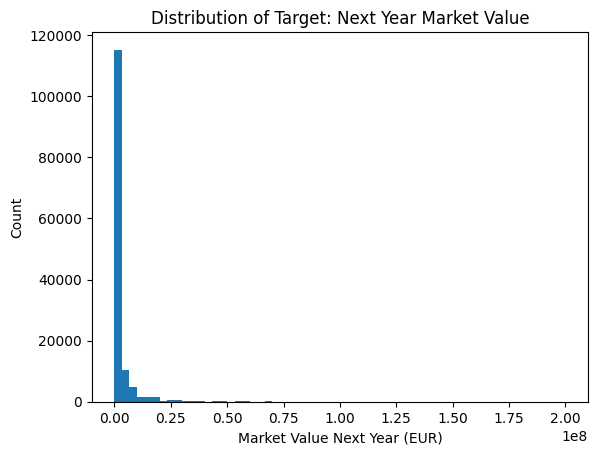

In [44]:

# -----------------------------
# 3.1 Basic statistics (target)
# -----------------------------
display(y.describe())

plt.figure()
plt.hist(y, bins=60)
plt.xlabel("Market Value Next Year (EUR)")
plt.ylabel("Count")
plt.title("Distribution of Target: Next Year Market Value")
plt.show()


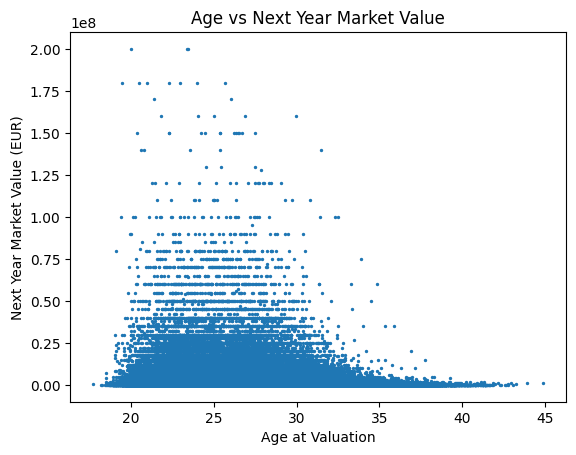

In [45]:

# -----------------------------
# 3.2 Relationship: age vs next-year value
# -----------------------------
plt.figure()
plt.scatter(merged_df["age_at_valuation"], merged_df["market_value_next_year"], s=2)
plt.xlabel("Age at Valuation")
plt.ylabel("Next Year Market Value (EUR)")
plt.title("Age vs Next Year Market Value")
plt.show()


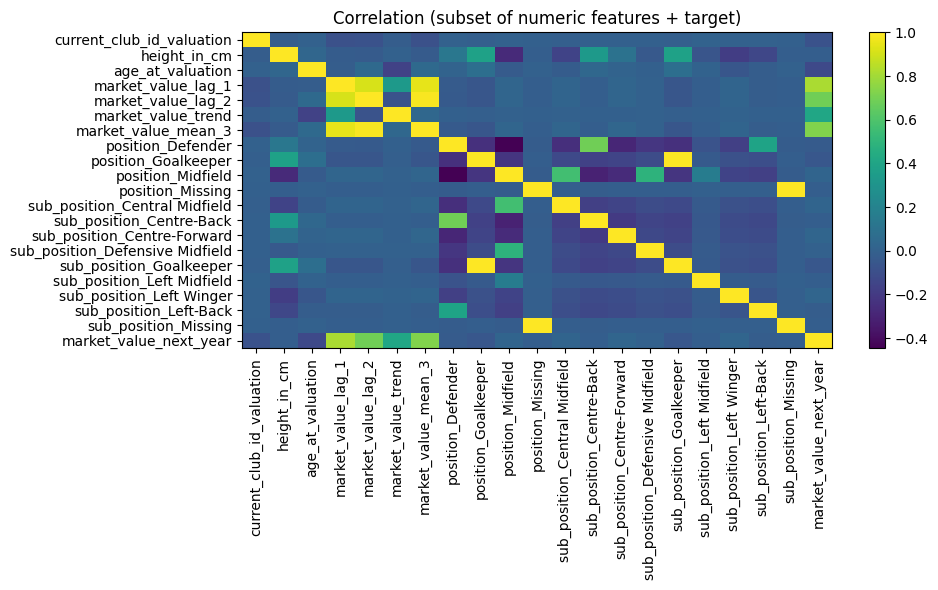

In [46]:

# -----------------------------
# 3.3 Correlation heatmap (numeric subset)
# -----------------------------
num_cols = X.columns[:20]  # limit for readability
corr = pd.concat([X[num_cols], y], axis=1).corr()

plt.figure(figsize=(10,6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation (subset of numeric features + target)")
plt.tight_layout()
plt.show()


## 4. Data Analytics (Modeling)
This is a **supervised learning regression** problem. We compare multiple algorithms and evaluate them using MAE, RMSE, and R². We also do time-aware train/test splitting to reduce leakage risk.

In [47]:

# -----------------------------
# 4.1 Train/Test split (time-aware)
# -----------------------------
# We preserve order (shuffle=False) because data is time-dependent.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (110807, 40) (110807,)
Test: (27702, 40) (27702,)


### 4.2 Train multiple models and evaluate
We compare:
- Linear Regression (baseline)
- ElasticNet (regularized linear)
- Random Forest (non-linear)
- KNN (distance-based)

For KNN and ElasticNet we benefit from scaling, so we use pipelines.

In [48]:

# -----------------------------
# 4.2 Models + evaluation
# -----------------------------
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_te, pred),
        "RMSE": np.sqrt(mean_squared_error(y_te, pred)),
        "R2": r2_score(y_te, pred)
    }

models = []

# Baselines (no scaling needed)
models.append(("Linear Regression", LinearRegression()))
models.append(("Random Forest", RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    random_state=42,
    n_jobs=-1
)))

# Pipelines (imputer + scaler) helps for KNN/ElasticNet
elastic_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42))
])

knn_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=10))
])

models.append(("ElasticNet (scaled)", elastic_pipe))
models.append(("KNN (scaled)", knn_pipe))

results = []
for name, model in models:
    results.append(evaluate_model(name, model, X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("MAE")
results_df


,Model,MAE,RMSE,R2
1,Random Forest,2.108117e+06,5.879620e+06,0.687193
0,Linear Regression,2.278300e+06,5.701673e+06,0.705841
3,KNN (scaled),2.285247e+06,6.252842e+06,0.646221
2,ElasticNet (scaled),2.302445e+06,5.770425e+06,0.698704


### 4.3 Cross-validation (time series)
We use `TimeSeriesSplit` to evaluate models with time-aware cross-validation. This avoids mixing future information into training folds.

In [49]:

# -----------------------------
# 4.3 TimeSeries cross-validation (on a subset for speed)
# -----------------------------
tscv = TimeSeriesSplit(n_splits=5)

# For speed, sample a subset (optional). Remove sampling if you have time.
sample_size = min(120000, len(X_train))
X_cv = X_train.iloc[:sample_size]
y_cv = y_train.iloc[:sample_size]

# Use MAE (negative in sklearn scoring conventions)
def cv_mae(model):
    scores = cross_val_score(
        model, X_cv, y_cv,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )
    return -scores.mean(), scores.std()

cv_rows = []
for name, model in models:
    mean_mae, std_mae = cv_mae(model)
    cv_rows.append({"Model": name, "CV_MAE_mean": mean_mae, "CV_MAE_std": std_mae})

cv_df = pd.DataFrame(cv_rows).sort_values("CV_MAE_mean")
cv_df


,Model,CV_MAE_mean,CV_MAE_std
1,Random Forest,1.272931e+06,184340.880386
0,Linear Regression,1.481909e+06,162446.529953
2,ElasticNet (scaled),1.494259e+06,161227.808507
3,KNN (scaled),1.538484e+06,138336.576371


### 4.4 Feature importance (Random Forest)
We inspect which features contribute most to predictions (interpretability).

market_value_lag_1                       0.689571
age_at_valuation                         0.113415
current_club_id_valuation                0.036594
height_in_cm                             0.028135
market_value_mean_3                      0.026147
market_value_trend                       0.024185
market_value_lag_2                       0.014798
domestic_competition_id_valuation_GB1    0.005909
sub_position_Centre-Forward              0.005751
domestic_competition_id_valuation_FR1    0.005747
domestic_competition_id_valuation_ES1    0.004856
sub_position_Right Winger                0.003330
sub_position_Left Winger                 0.003259
position_Midfield                        0.003169
foot_left                                0.003091
dtype: float64

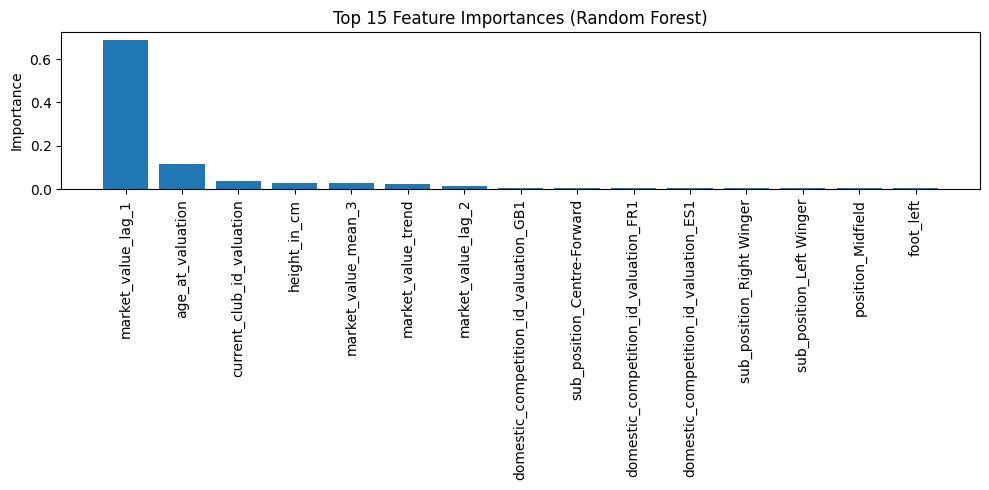

In [50]:
# -----------------------------------------
# 4.4 Feature importance (Random Forest) – FIXED
# -----------------------------------------

from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Compute importances
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Display top features as table
top_k = 15
display(importances.head(top_k))

# Plot feature importances (safe 1D float arrays)
top_feats = importances.head(top_k)
x = np.arange(len(top_feats))
y = top_feats.to_numpy(dtype=float)

plt.figure(figsize=(10, 5))
plt.bar(x, y)
plt.xticks(x, top_feats.index, rotation=90)
plt.ylabel("Importance")
plt.title(f"Top {top_k} Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


### 4.5 Predicted vs actual plot
A quick diagnostic plot to visually assess model fit.

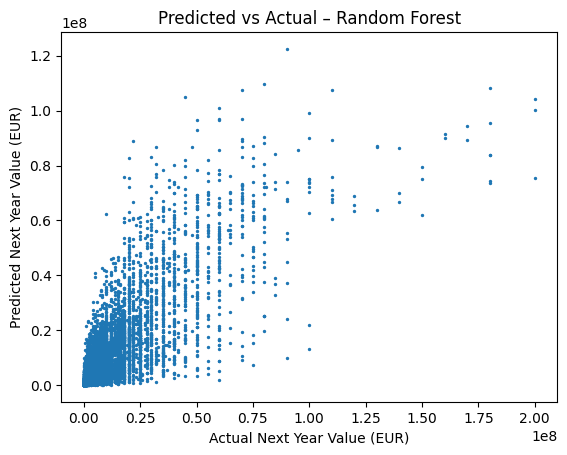

In [53]:

# -----------------------------
# 4.5 Predicted vs actual
# -----------------------------
best_model_name = results_df.iloc[0]["Model"]
best_model = dict(models)[best_model_name]
best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

plt.figure()
plt.scatter(y_test, pred, s=2)
plt.xlabel("Actual Next Year Value (EUR)")
plt.ylabel("Predicted Next Year Value (EUR)")
plt.title(f"Predicted vs Actual – {best_model_name}")
plt.show()


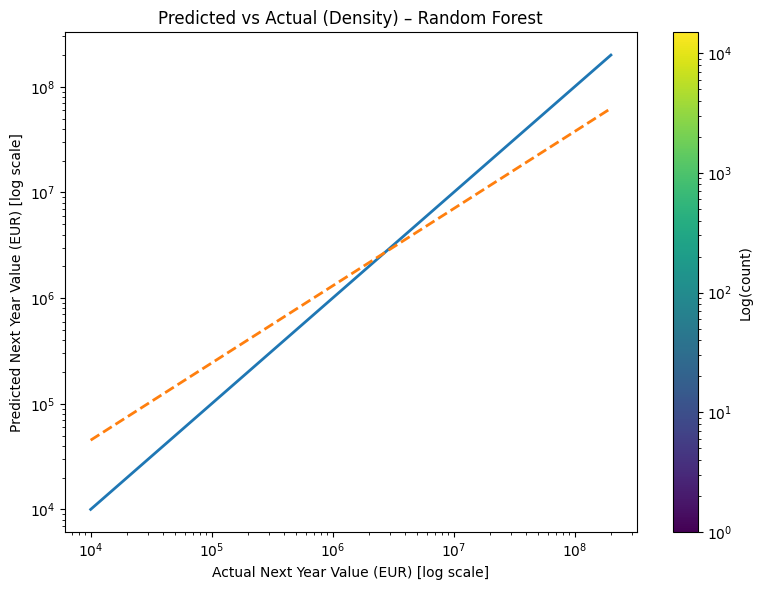

In [54]:
# -----------------------------
# 4.5 Predicted vs Actual (BEST visualization)
# -----------------------------
best_model_name = results_df.iloc[0]["Model"]
best_model = dict(models)[best_model_name]

best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

# Convert to numpy arrays (safe) and remove non-positive values for log scaling
y_true = np.asarray(y_test).astype(float)
y_pred = np.asarray(pred).astype(float)

mask = (y_true > 0) & (y_pred > 0) & np.isfinite(y_true) & np.isfinite(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

# 1) HEXBIN DENSITY PLOT (best when there are many points)
plt.figure(figsize=(8, 6))
hb = plt.hexbin(y_true, y_pred, gridsize=60, bins='log')  # density in log bins
plt.colorbar(hb, label="Log(count)")

# Log scales (makes long-tail readable)
plt.xscale("log")
plt.yscale("log")

# 45-degree line (perfect predictions)
min_v = min(y_true.min(), y_pred.min())
max_v = max(y_true.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], linewidth=2)

# Optional: simple trend line in log space
# Fit line to log10 values to show overall calibration
logx = np.log10(y_true)
logy = np.log10(y_pred)
m, b = np.polyfit(logx, logy, 1)
x_line = np.logspace(np.log10(min_v), np.log10(max_v), 200)
y_line = 10**(m*np.log10(x_line) + b)
plt.plot(x_line, y_line, linestyle="--", linewidth=2)

plt.xlabel("Actual Next Year Value (EUR) [log scale]")
plt.ylabel("Predicted Next Year Value (EUR) [log scale]")
plt.title(f"Predicted vs Actual (Density) – {best_model_name}")
plt.tight_layout()
plt.show()


## 5. Summary / Conclusions

- We framed the task as **supervised regression** to predict next-year market value.  
- We used **time-aware feature engineering** (lags, trends, rolling means) and a **time-aware train/test split** to reduce leakage risk.  
- We compared multiple models and evaluated them with **MAE, RMSE, and R²**, then validated via **TimeSeriesSplit** cross-validation.  

**Next improvements (if more time):**  
- Add performance stats (goals/assists/minutes) from `appearances.csv` to enrich features  
- Tune hyperparameters (GridSearchCV)  
- Try Gradient Boosting models (e.g., XGBoost / LightGBM) if allowed  
